In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('songs_normalize.csv')
print(df.shape)
print(df.columns.tolist())

(2000, 18)
['artist', 'song', 'duration_ms', 'explicit', 'year', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'genre']


In [2]:
print(df.head())


           artist                    song  duration_ms  explicit  year  \
0  Britney Spears  Oops!...I Did It Again       211160     False  2000   
1       blink-182    All The Small Things       167066     False  1999   
2      Faith Hill                 Breathe       250546     False  1999   
3        Bon Jovi            It's My Life       224493     False  2000   
4          *NSYNC             Bye Bye Bye       200560     False  2000   

   popularity  danceability  energy  key  loudness  mode  speechiness  \
0          77         0.751   0.834    1    -5.444     0       0.0437   
1          79         0.434   0.897    0    -4.918     1       0.0488   
2          66         0.529   0.496    7    -9.007     1       0.0290   
3          78         0.551   0.913    0    -4.063     0       0.0466   
4          65         0.614   0.928    8    -4.806     0       0.0516   

   acousticness  instrumentalness  liveness  valence    tempo         genre  
0        0.3000          0.000018    0

artist
Tom Odell            88.0
The Neighbourhood    87.0
WILLOW               86.0
Lewis Capaldi        84.0
Gesaffelstein        84.0
Tame Impala          83.0
Billie Eilish        82.8
Alec Benjamin        82.0
MKTO                 82.0
girl in red          82.0
Name: popularity, dtype: float64


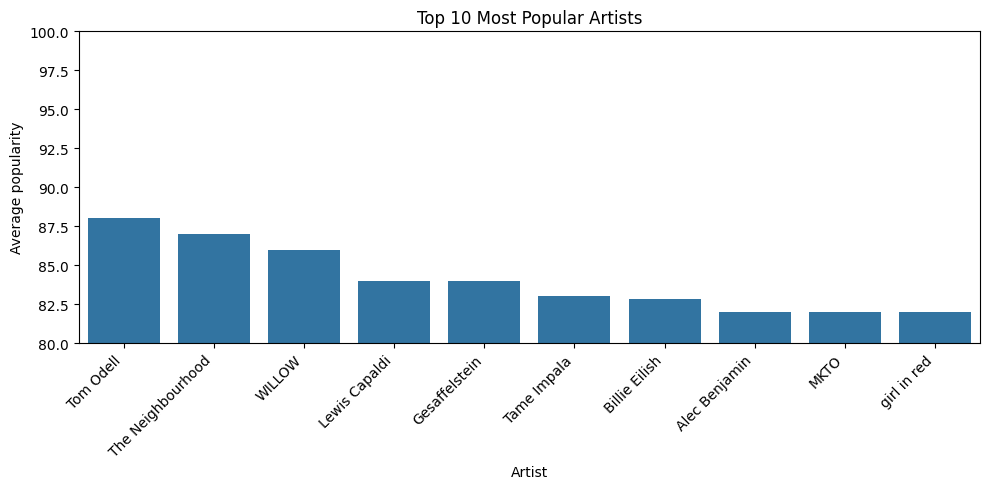

In [3]:
popu = df.groupby('artist')['popularity'].mean()

topten = popu.sort_values(ascending=False).head(10)

print(topten)

plt.figure(figsize=(10,5))
sns.barplot(x = topten.index , y = topten.values)
plt.title('Top 10 Most Popular Artists')
plt.xlabel('Artist')
plt.xticks(rotation=45,ha='right')
plt.ylabel('Average popularity')
plt.ylim(80,100)
plt.tight_layout()
plt.show()


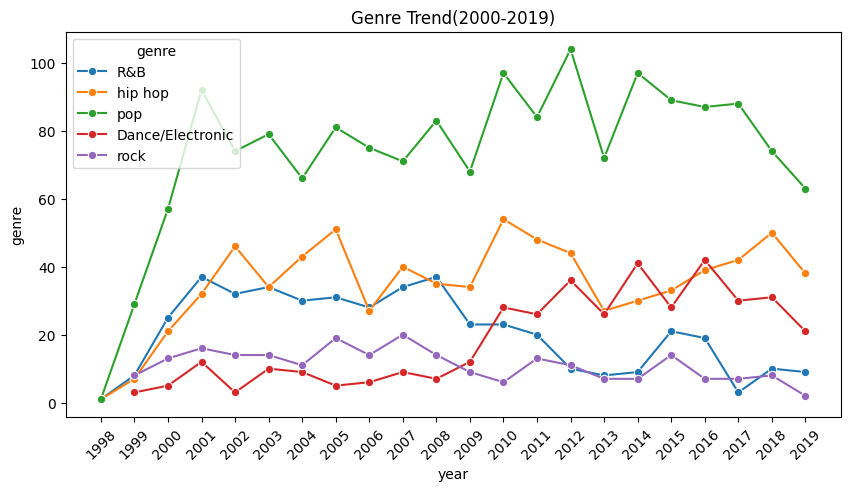

In [12]:
df_genre = df.assign(genre=df['genre'].str.split(',')).explode('genre')
df_genre['genre'] = df_genre['genre'].str.strip()
df_genre = df_genre[df_genre['genre'] != 'set()']

genre_trend = df_genre.groupby(['year','genre']).size().reset_index(name='count')
df_genre['genre'].value_counts().head(5)

top5 = ['pop','hip hop','R&B','Dance/Electronic','rock']
df_top5 = genre_trend[genre_trend['genre'].isin(top5) & (genre_trend['year'] <= 2019)]

plt.figure(figsize=(10,5))
sns.lineplot(data=df_top5,x='year' ,y='count',hue='genre',marker='o' )
plt.title('Genre Trend(2000-2019)')
plt.xlabel('year')
plt.xticks(range(1998, 2020), rotation=45)
plt.ylabel('genre')
plt.show()


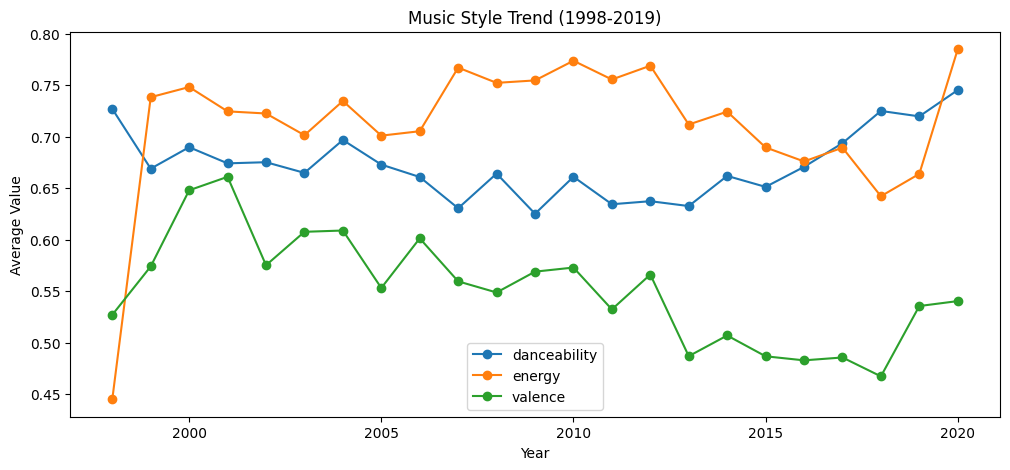

In [27]:
avg  = df.groupby('year')[['danceability', 'energy', 'valence']].mean()

plt.figure(figsize=(12,5))
avg.plot(ax=plt.gca(), marker='o')
plt.title('Music Style Trend (1998-2019)')
plt.xlabel('Year')
plt.ylabel('Average Value')
plt.legend()
plt.show()



# Spotify 音樂趨勢分析（2000–2019）

## 分析目標
分析1998-2019年spotify上歌曲受歡迎、類型趨勢、音樂風格變化

## 主要發現

### 1. 最受歡迎的歌手
Tom Odell、The Neighbourhood、WILLOW 是平均 popularity 最高的前三名，
多為獨立音樂風格，顯示 Spotify 用戶偏好小眾但高質量的音樂。
### 2. 類型趨勢
pop 稱霸全場 — 從 2000 到 2019 一直是主流，而且持續成長
hip hop 穩定佔據第二 — 不像 pop 那麼爆發，但很穩定，代表有固定受眾
R&B 和 rock 式微 — 這兩個類型逐漸被 pop 和 hip hop 取代，符合現實音樂市場的趨勢
Dance/Electronic 平穩 — 小眾但穩定

### 3. 音樂風格變化
音樂整體越來越憂鬱、負面，近年流行的歌（如 Billie Eilish、Lewis Capaldi）確實偏向暗黑風格，這個趨勢完全符合
2015 後下降 — 可能跟 lo-fi、acoustic 風格的興起有關，聽眾開始喜歡比較輕柔的音樂
即使 energy 下降，舞曲元素反而增加，代表現代流行音樂更注重節拍感


## 結論
1998–2019 年間，流行音樂市場由 Pop 和 Hip Hop 主導，Rock 和 R&B 逐漸式微。
音樂風格整體趨向憂鬱（valence 下降）但更有舞曲節拍感（danceability 上升），
反映聽眾口味從高能量轉向情感共鳴。
對音樂產業來說，主打情感共鳴的 Pop 和 Hip Hop 仍是最安全的投資方向。